### **📚Importing Important Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error

In [2]:
housing = pd.read_csv("Housing.csv")

In [3]:
housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


#### **Encoding boolean value**

In [4]:
le = LabelEncoder()

In [5]:
housing["mainroad"] = le.fit_transform(housing["mainroad"])
housing["guestroom"] = le.fit_transform(housing["guestroom"])
housing["basement"] = le.fit_transform(housing["basement"])
housing["hotwaterheating"] = le.fit_transform(housing["hotwaterheating"])
housing["airconditioning"] = le.fit_transform(housing["airconditioning"])
housing["prefarea"] = le.fit_transform(housing["prefarea"])
housing["furnishingstatus"] = le.fit_transform(housing["furnishingstatus"])
housing



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,2
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,2
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0


#### **Finding Corelations**

In [6]:
corr_matrix = housing.corr()

In [7]:
corr_matrix["price"].sort_values(ascending=False)

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
furnishingstatus   -0.304721
Name: price, dtype: float64

#### **Visualizing some attributes**

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='area', ylabel='price'>,
        <Axes: xlabel='bathrooms', ylabel='price'>,
        <Axes: xlabel='airconditioning', ylabel='price'>,
        <Axes: xlabel='stories', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='area'>,
        <Axes: xlabel='area', ylabel='area'>,
        <Axes: xlabel='bathrooms', ylabel='area'>,
        <Axes: xlabel='airconditioning', ylabel='area'>,
        <Axes: xlabel='stories', ylabel='area'>],
       [<Axes: xlabel='price', ylabel='bathrooms'>,
        <Axes: xlabel='area', ylabel='bathrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bathrooms'>,
        <Axes: xlabel='airconditioning', ylabel='bathrooms'>,
        <Axes: xlabel='stories', ylabel='bathrooms'>],
       [<Axes: xlabel='price', ylabel='airconditioning'>,
        <Axes: xlabel='area', ylabel='airconditioning'>,
        <Axes: xlabel='bathrooms', ylabel='airconditioning'>,
        <Axes: xlabel='airconditioning',

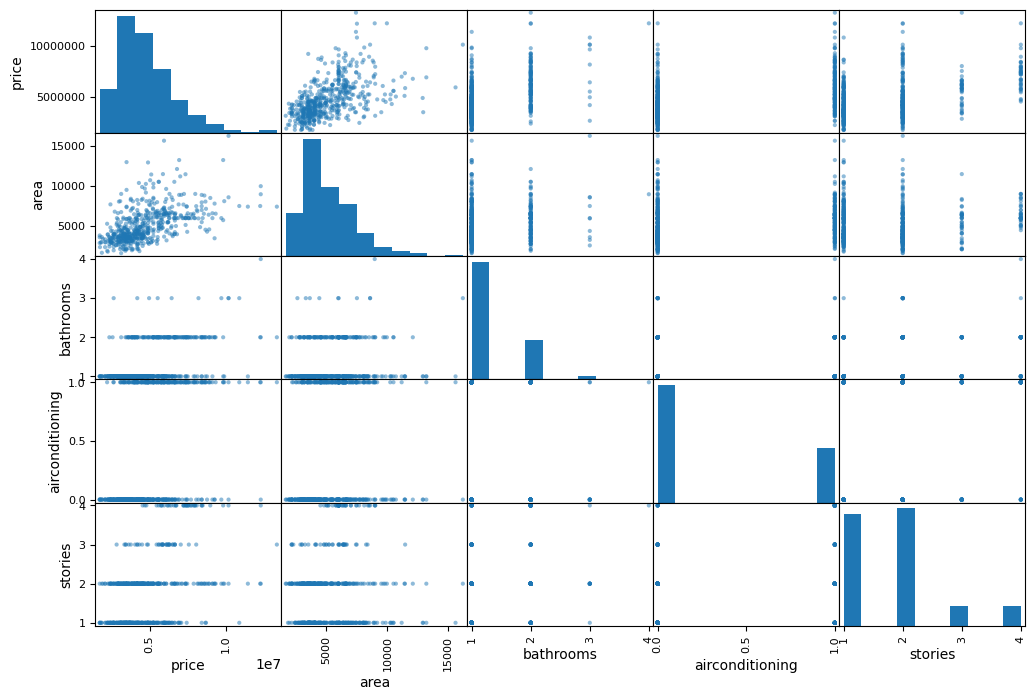

In [8]:
attributes = ['price','area','bathrooms','airconditioning','stories']
scatter_matrix(housing[attributes], figsize=(12,8))

#### **Distributing the label and features**

In [9]:
X = housing.drop(columns=["price"])
y = housing["price"]

In [10]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,2
541,2400,3,1,1,0,0,0,0,0,0,0,1
542,3620,2,1,1,1,0,0,0,0,0,0,2
543,2910,3,1,1,0,0,0,0,0,0,0,0


In [11]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

#### **Visualizing the Data**

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'mainroad'}>,
        <Axes: title={'center': 'guestroom'}>,
        <Axes: title={'center': 'basement'}>],
       [<Axes: title={'center': 'hotwaterheating'}>,
        <Axes: title={'center': 'airconditioning'}>,
        <Axes: title={'center': 'parking'}>,
        <Axes: title={'center': 'prefarea'}>],
       [<Axes: title={'center': 'furnishingstatus'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

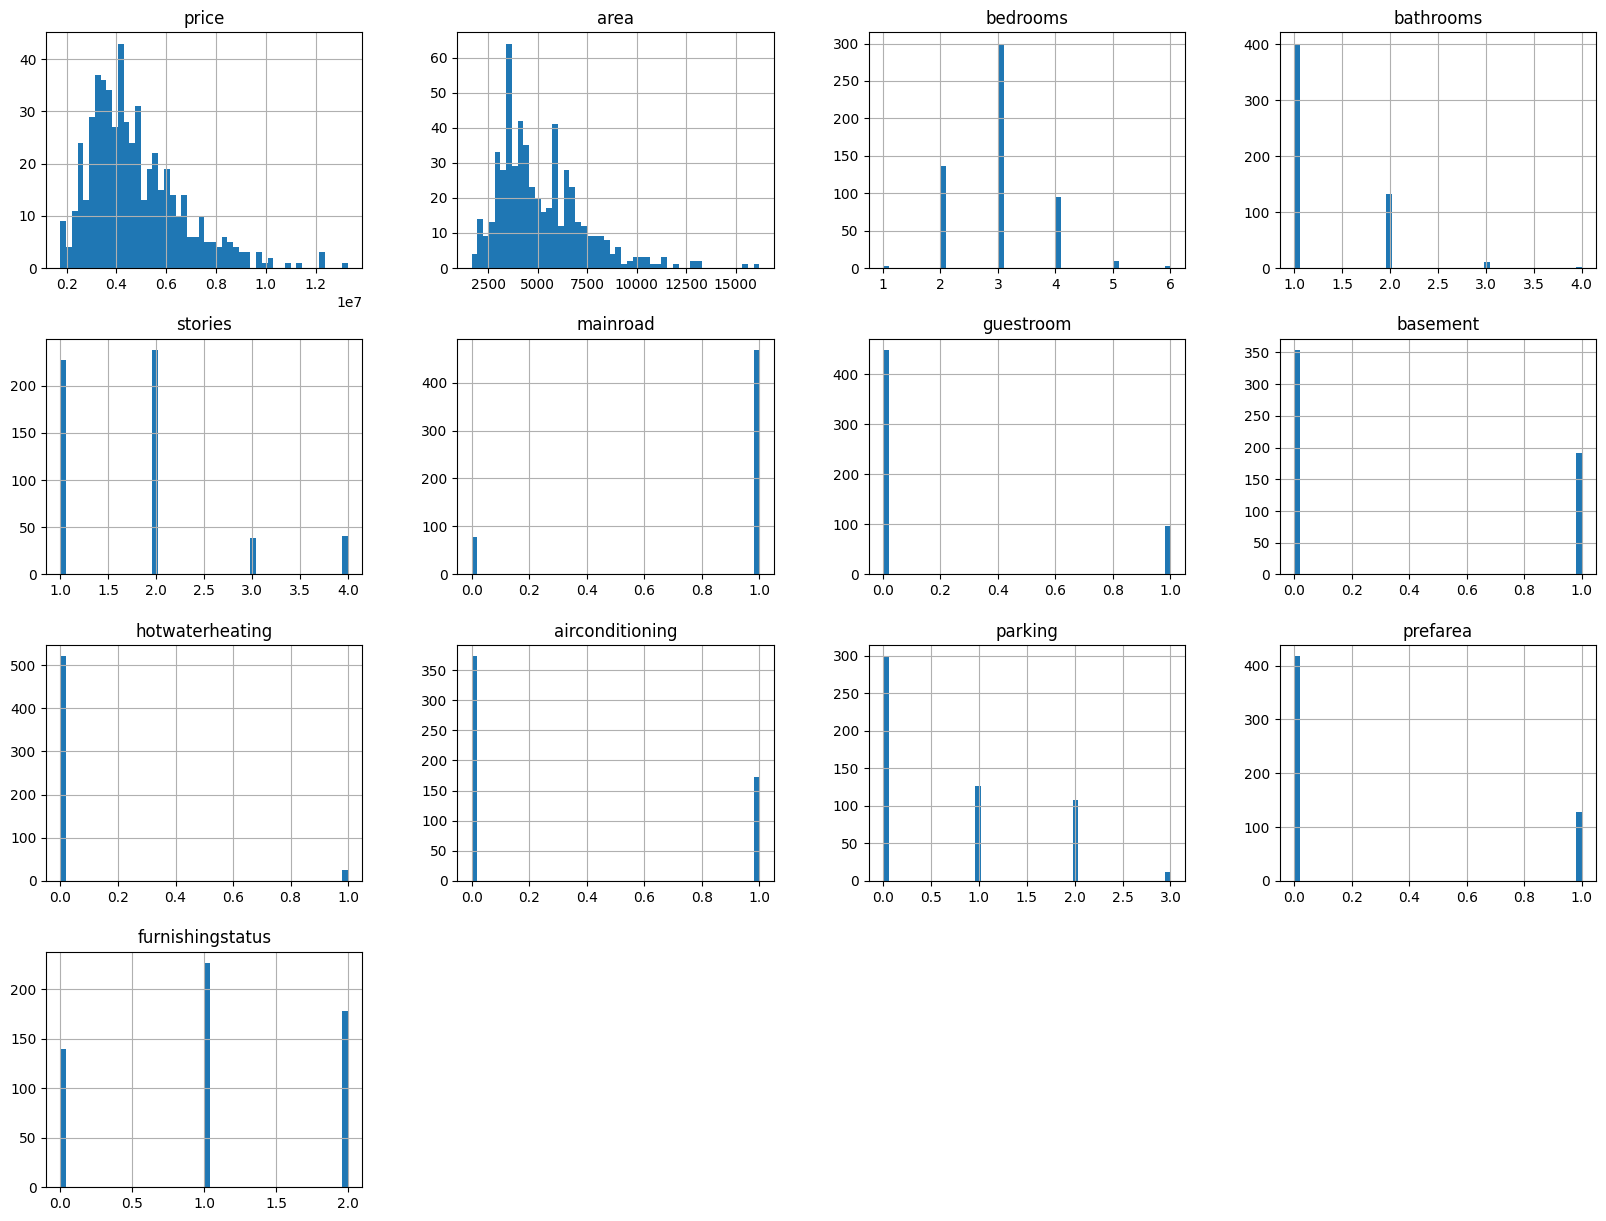

In [12]:
housing.hist(bins=50, figsize=(20,15))

In [13]:
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size= 0.2, random_state=42, shuffle=True)


#### **Testing Some Models**

In [14]:
test_pipeline = Pipeline([('std_scaler', StandardScaler()),('model', LinearRegression())])
test_pipeline.fit(X_train,y_train)
some_features = X_train.iloc[:5]
some_labels = y_train.iloc[:5]
test_predictions = test_pipeline.predict(some_features)


**Evaluating MSE AND RMSE**

In [17]:
train_mse = mean_squared_error(some_labels,test_predictions)
train_rmse = np.sqrt(train_mse)
train_mse

344685395458.7445

In [18]:
train_rmse

np.float64(587099.1359717237)

#### **Creating a Pipeline**

In [ ]:
pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),('std_scaler', StandardScaler()),('model', )])